# 06 — Baseline decoding models

I train classical decoders before using advanced models. This notebook treats real movie-frame visual statistics as decoding targets, handles imbalanced and ambiguous dominant-orientation labels explicitly, and reports null baselines. I treat continuous visual-feature decoding as the primary analysis; coarse/confident orientation decoding is secondary or exploratory.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from v1_manifold.config import load_config, get_paths, set_global_seed
from v1_manifold.visualization import set_publication_style, save_figure
from v1_manifold.utils import save_table

cfg = load_config(ROOT / "configs" / "default.yaml")
cfg["paths"]["root"] = str(ROOT)
paths = get_paths(cfg)
set_global_seed(cfg["project"]["random_seed"])
set_publication_style()
print(f"Project root: {ROOT}")

Project root: c:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies


In [2]:
import numpy as np
import pandas as pd
from v1_manifold.models import evaluate_decoders, evaluate_regressors, save_fitted_models, valid_embedding_names, describe_embedding_file
from v1_manifold.preprocessing import load_trial_tensor_h5
from v1_manifold.features import (
    assert_real_stimulus_features,
    make_single_trial_design_matrix,
    add_coarse_orientation_target,
    add_confident_orientation_target,
    summarize_class_balance,
    safe_classification_target,
    balanced_confident_orientation_subset,
)
from v1_manifold.visualization import plot_metric_bar, plot_confusion_matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

h5_files = sorted(paths.interim_dir.glob("session_*_tensor.h5"))
emb_files = sorted(paths.processed_dir.glob("session_*_embeddings.npz"))
if not h5_files:
    raise FileNotFoundError("No trial tensor exists yet. I need to run notebook 03 first.")
if not emb_files:
    raise FileNotFoundError("No embeddings exist yet. I need to run notebook 05 first.")

tensor_path = h5_files[0]
emb_path = emb_files[0]
session_id = emb_path.name.split("_")[1]

feature_candidates = sorted(paths.processed_dir.glob(f"session_{session_id}*_frame_features.csv"))
if not feature_candidates:
    raise FileNotFoundError("Frame features not found. I need to run notebook 04 first.")
features = pd.read_csv(feature_candidates[0])
assert_real_stimulus_features(features)
if "dominant_orientation_coarse" not in features.columns:
    features = add_coarse_orientation_target(
        features,
        top_k=cfg["features"].get("coarse_orientation_top_k", 2),
    )
if "dominant_orientation_confident" not in features.columns:
    features = add_confident_orientation_target(
        features,
        confidence_quantile=cfg["features"].get("orientation_confidence_quantile", 0.50),
        ambiguous_label=cfg["features"].get("orientation_ambiguous_label", "ambiguous"),
    )

# I evaluate two complementary decoding settings:
# 1) frame-level decoding from latent embeddings, and
# 2) repeat-wise held-out single-trial decoding from raw neural activity.
emb = np.load(emb_path)
tensor, R = load_trial_tensor_h5(tensor_path)
X_trial, repeat_group, frame_idx = make_single_trial_design_matrix(tensor)

# The embeddings file can also contain metadata arrays such as PCA variance spectra.
# I keep only arrays shaped as frame-level embeddings: [n_movie_frames, n_latent_dimensions].
embedding_summary = describe_embedding_file(emb, n_samples=len(features))
save_table(embedding_summary, paths.tables_dir / f"06_embedding_file_summary_session_{session_id}.csv")
display(embedding_summary)

embedding_names = valid_embedding_names(emb, n_samples=len(features))
if not embedding_names:
    raise ValueError(
        "No valid 2D frame-level embeddings were found in the embeddings file. "
        "I need notebook 05 to save arrays such as pca, umap, isomap, or cebra with one row per movie frame."
    )
print("Valid frame-level embeddings used for latent decoding:", embedding_names)

# I make the label imbalance explicit before training any classifier.
class_balance_tables = []
for target in ["dominant_orientation_bin", "dominant_orientation_coarse", "dominant_orientation_confident", "spatial_frequency_bin"]:
    if target in features.columns:
        tab = summarize_class_balance(features[target], target_name=target)
        tab.insert(0, "target", target)
        class_balance_tables.append(tab)
class_balance = pd.concat(class_balance_tables, ignore_index=True)
save_table(class_balance, paths.tables_dir / "06_classification_target_balance.csv")
display(class_balance)

classification_targets = {
    "dominant_orientation_coarse_secondary": features["dominant_orientation_coarse"].to_numpy(),
    "dominant_orientation_confident_exploratory": features["dominant_orientation_confident"].to_numpy(),
    "spatial_frequency_bin_secondary": features["spatial_frequency_bin"].to_numpy(),
    # Fine 8-bin orientation is kept as exploratory because it is often highly imbalanced.
    "dominant_orientation_bin_fine_exploratory": features["dominant_orientation_bin"].to_numpy(),
}

# I skip classification targets that do not have enough support for cross-validation.
classification_targets = {
    name: y for name, y in classification_targets.items()
    if safe_classification_target(y, min_classes=2, min_count_per_class=2)
}

# I construct a stricter balanced confident-orientation subset by excluding ambiguous
# frames and downsampling the majority confident class. This is intentionally small
# and exploratory, but it is fairer than decoding the full imbalanced labels.
balanced_confident = balanced_confident_orientation_subset(
    features,
    random_state=cfg["project"]["random_seed"],
)
if not balanced_confident.empty:
    save_table(
        summarize_class_balance(
            balanced_confident["dominant_orientation_confident"],
            target_name="dominant_orientation_confident_balanced",
        ),
        paths.tables_dir / "06_balanced_confident_orientation_subset_balance.csv",
    )

regression_targets = {
    "rms_contrast": features["rms_contrast"].to_numpy(),
    "spatial_frequency_centroid": features["spatial_frequency_centroid"].to_numpy(),
    "orientation_selectivity": features["orientation_selectivity"].to_numpy(),
    "luminance_std": features["luminance_std"].to_numpy(),
    "total_spectral_power": features["total_spectral_power"].to_numpy(),
}

rows = []
all_predictions = {}
include_nulls = cfg["evaluation"].get("include_null_baselines", True)

# Frame-level latent decoding. This asks whether learned manifold coordinates preserve real visual features.
# I interpret this as exploratory because adjacent movie frames are autocorrelated.
for target_name, y_frame in classification_targets.items():
    for embedding_name in embedding_names:
        df, preds, fitted = evaluate_decoders(
            emb[embedding_name],
            y_frame,
            n_splits=cfg["evaluation"]["n_splits"],
            random_state=cfg["project"]["random_seed"],
            include_null_baselines=include_nulls,
        )
        df.insert(0, "target", target_name)
        df.insert(1, "analysis", "frame_level_latent_exploratory")
        df.insert(2, "embedding", embedding_name)
        rows.append(df)
        all_predictions[("frame_level_latent_exploratory", target_name, embedding_name)] = preds
        save_fitted_models(fitted, paths.models_dir, prefix=f"session_{session_id}_{embedding_name}_{target_name}")

# Repeat-wise single-trial decoding. This is the more neuroscience-faithful held-out-repeat test.
for target_name, y_frame in classification_targets.items():
    y_trial = y_frame[frame_idx]
    df, preds, fitted = evaluate_decoders(
        X_trial,
        y_trial,
        groups=repeat_group,
        n_splits=min(cfg["evaluation"]["n_splits"], len(np.unique(repeat_group))),
        random_state=cfg["project"]["random_seed"],
        include_null_baselines=include_nulls,
    )
    df.insert(0, "target", target_name)
    df.insert(1, "analysis", "single_trial_repeat_heldout")
    df.insert(2, "embedding", "raw_cells")
    rows.append(df)
    all_predictions[("single_trial_repeat_heldout", target_name, "raw_cells")] = preds
    save_fitted_models(fitted, paths.models_dir, prefix=f"session_{session_id}_raw_cells_{target_name}")

# Balanced confident-only orientation decoding: secondary/exploratory analysis.
if not balanced_confident.empty and safe_classification_target(
    balanced_confident["dominant_orientation_confident"],
    min_classes=2,
    min_count_per_class=2,
):
    target_name = "dominant_orientation_confident_balanced_binary_exploratory"
    frame_subset = balanced_confident["movie_frame"].astype(int).to_numpy()
    y_balanced = balanced_confident["dominant_orientation_confident"].to_numpy()

    for embedding_name in embedding_names:
        df, preds, fitted = evaluate_decoders(
            emb[embedding_name][frame_subset],
            y_balanced,
            n_splits=min(cfg["evaluation"]["n_splits"], pd.Series(y_balanced).value_counts().min()),
            random_state=cfg["project"]["random_seed"],
            include_null_baselines=include_nulls,
        )
        df.insert(0, "target", target_name)
        df.insert(1, "analysis", "balanced_confident_frame_level_exploratory")
        df.insert(2, "embedding", embedding_name)
        rows.append(df)
        all_predictions[("balanced_confident_frame_level_exploratory", target_name, embedding_name)] = preds
        save_fitted_models(fitted, paths.models_dir, prefix=f"session_{session_id}_{embedding_name}_{target_name}")

    frame_to_label = dict(zip(frame_subset, y_balanced))
    trial_mask = np.isin(frame_idx, frame_subset)
    y_trial_balanced = np.array([frame_to_label[int(i)] for i in frame_idx[trial_mask]])
    df, preds, fitted = evaluate_decoders(
        X_trial[trial_mask],
        y_trial_balanced,
        groups=repeat_group[trial_mask],
        n_splits=min(cfg["evaluation"]["n_splits"], len(np.unique(repeat_group[trial_mask]))),
        random_state=cfg["project"]["random_seed"],
        include_null_baselines=include_nulls,
    )
    df.insert(0, "target", target_name)
    df.insert(1, "analysis", "balanced_confident_single_trial_repeat_heldout")
    df.insert(2, "embedding", "raw_cells")
    rows.append(df)
    all_predictions[("balanced_confident_single_trial_repeat_heldout", target_name, "raw_cells")] = preds
    save_fitted_models(fitted, paths.models_dir, prefix=f"session_{session_id}_raw_cells_{target_name}")

if not rows:
    raise RuntimeError("No classification targets had enough support for cross-validation.")

benchmark = pd.concat(rows, ignore_index=True)
benchmark.insert(0, "session_id", session_id)
save_table(benchmark, paths.tables_dir / "06_baseline_decoding_benchmark.csv")
display(benchmark.sort_values(["target", "balanced_accuracy"], ascending=[True, False]).head(20))

# Continuous visual-feature decoding from held-out repeats. This is the primary stimulus-decoding analysis.
regression_rows = []
for target_name, y_frame in regression_targets.items():
    y_trial = y_frame[frame_idx]
    df, preds, fitted = evaluate_regressors(
        X_trial,
        y_trial,
        groups=repeat_group,
        n_splits=min(cfg["evaluation"]["n_splits"], len(np.unique(repeat_group))),
        random_state=cfg["project"]["random_seed"],
    )
    df.insert(0, "session_id", session_id)
    df.insert(1, "target", target_name)
    df.insert(2, "analysis", "single_trial_repeat_heldout")
    df.insert(3, "embedding", "raw_cells")
    regression_rows.append(df)
    save_fitted_models(fitted, paths.models_dir, prefix=f"session_{session_id}_raw_cells_{target_name}_regression")

regression_benchmark = pd.concat(regression_rows, ignore_index=True)
save_table(regression_benchmark, paths.tables_dir / "06_continuous_feature_decoding_benchmark.csv")
display(regression_benchmark.sort_values("r2", ascending=False).head(20))

,array_name,shape,ndim,is_valid_frame_embedding
0,pca,"(900, 3)",2,True
1,pca_full,"(900, 20)",2,True
2,umap,"(900, 3)",2,True
3,isomap,"(900, 3)",2,True
4,frame,"(900,)",1,False
5,rms_contrast,"(900,)",1,False
6,spatial_frequency_centroid,"(900,)",1,False


Valid frame-level embeddings used for latent decoding: ['pca', 'pca_full', 'umap', 'isomap']


,target,dominant_orientation_bin,n_samples,fraction,majority_class,dominant_orientation_coarse,dominant_orientation_confident,spatial_frequency_bin
0,dominant_orientation_bin,0.0,13,0.014444,False,NaN,NaN,NaN
1,dominant_orientation_bin,1.0,33,0.036667,False,NaN,NaN,NaN
2,dominant_orientation_bin,3.0,557,0.618889,True,NaN,NaN,NaN
3,dominant_orientation_bin,4.0,287,0.318889,False,NaN,NaN,NaN
4,dominant_orientation_bin,6.0,8,0.008889,False,NaN,NaN,NaN
5,dominant_orientation_bin,7.0,2,0.002222,False,NaN,NaN,NaN
6,dominant_orientation_coarse,NaN,557,0.618889,True,bin_3,NaN,NaN
7,dominant_orientation_coarse,NaN,287,0.318889,False,bin_4,NaN,NaN
8,dominant_orientation_coarse,NaN,56,0.062222,False,other,NaN,NaN
9,dominant_orientation_confident,NaN,450,0.500000,True,NaN,ambiguous,NaN


,session_id,target,analysis,embedding,accuracy,balanced_accuracy,macro_f1,model,n_samples,n_features,is_null_baseline
72,500855614,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,pca_full,0.870000,0.820505,0.586829,ridge_classifier,900,20,False
73,500855614,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,pca_full,0.953333,0.784087,0.739938,logistic_regression,900,20,False
80,500855614,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,umap,0.957778,0.722396,0.731859,random_forest,900,3,False
74,500855614,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,pca_full,0.953333,0.714030,0.705270,linear_svm,900,20,False
75,500855614,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,pca_full,0.962222,0.705189,0.720625,random_forest,900,20,False
81,500855614,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,umap,0.953333,0.699257,0.705280,gradient_boosting,900,3,False
76,500855614,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,pca_full,0.946667,0.692225,0.715204,gradient_boosting,900,20,False
82,500855614,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,umap,0.546667,0.638181,0.336843,ridge_classifier,900,3,False
112,500855614,dominant_orientation_bin_fine_exploratory,single_trial_repeat_heldout,raw_cells,0.671889,0.621169,0.415342,ridge_classifier,9000,163,False
88,500855614,dominant_orientation_bin_fine_exploratory,frame_level_latent_exploratory,isomap,0.918889,0.609500,0.625152,gradient_boosting,900,3,False


c:\Users\Peter\.neuro\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.335e+09, tolerance: 4.816e+08
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Peter\.neuro\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.025e+11, tolerance: 4.816e+08
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Peter\.neuro\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.369e+11, toleran

,session_id,target,analysis,embedding,mae,rmse,r2,model,n_samples,n_features
16,500855614,total_spectral_power,single_trial_repeat_heldout,raw_cells,15455.182967,21177.296663,0.562762,random_forest_regressor,9000,163
12,500855614,luminance_std,single_trial_repeat_heldout,raw_cells,0.004443,0.006865,0.528322,random_forest_regressor,9000,163
0,500855614,rms_contrast,single_trial_repeat_heldout,raw_cells,0.008275,0.012827,0.522509,random_forest_regressor,9000,163
1,500855614,rms_contrast,single_trial_repeat_heldout,raw_cells,0.009734,0.013360,0.482062,gradient_boosting_regressor,9000,163
13,500855614,luminance_std,single_trial_repeat_heldout,raw_cells,0.005282,0.007198,0.481484,gradient_boosting_regressor,9000,163
17,500855614,total_spectral_power,single_trial_repeat_heldout,raw_cells,17906.774125,23165.083572,0.476827,gradient_boosting_regressor,9000,163
8,500855614,orientation_selectivity,single_trial_repeat_heldout,raw_cells,0.046945,0.064503,0.471925,random_forest_regressor,9000,163
9,500855614,orientation_selectivity,single_trial_repeat_heldout,raw_cells,0.050871,0.065349,0.457990,gradient_boosting_regressor,9000,163
4,500855614,spatial_frequency_centroid,single_trial_repeat_heldout,raw_cells,0.006456,0.008813,0.404585,random_forest_regressor,9000,163
5,500855614,spatial_frequency_centroid,single_trial_repeat_heldout,raw_cells,0.007066,0.008992,0.380216,gradient_boosting_regressor,9000,163


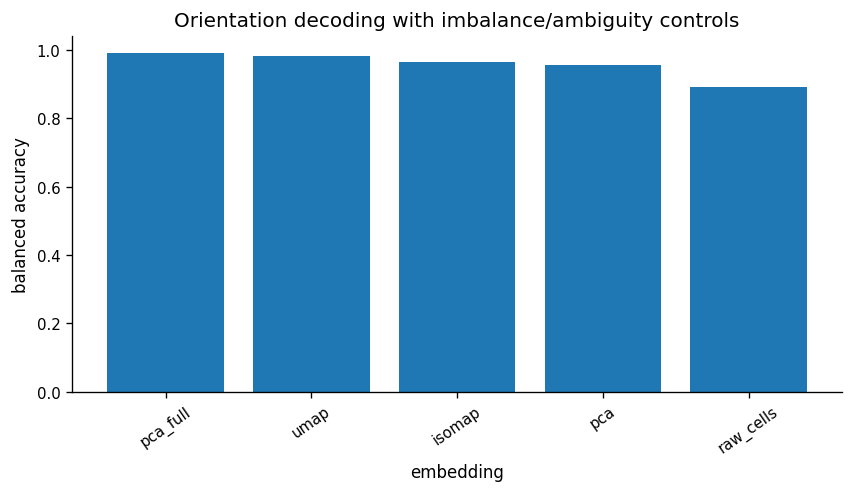

In [3]:
plot_df = benchmark[benchmark["target"].str.contains("dominant_orientation", na=False)].copy()

fig = plot_metric_bar(
    plot_df,
    x="embedding",
    y="balanced_accuracy",
    title="Orientation decoding with imbalance/ambiguity controls",
)
save_figure(fig, paths.figures_dir / "06_coarse_orientation_decoding_comparison.png")
plt.show()

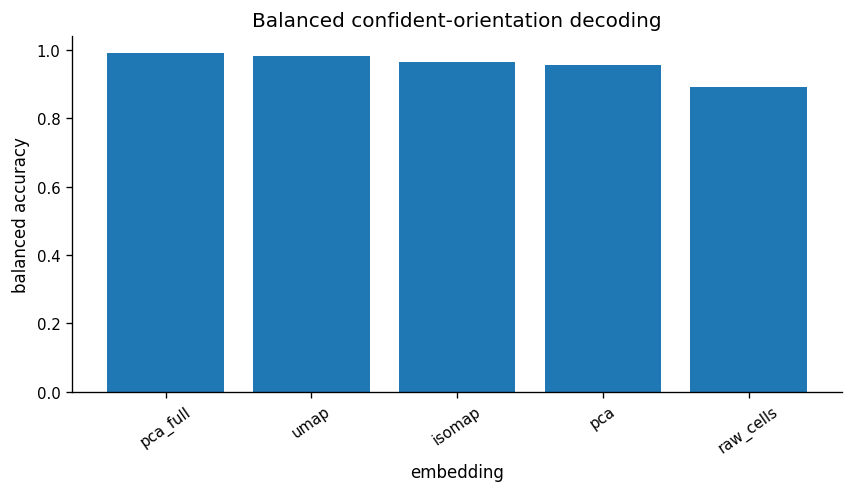

In [5]:
plot_df = benchmark[
    (~benchmark["is_null_baseline"].astype(bool))
    & (benchmark["target"] == "dominant_orientation_confident_balanced_binary_exploratory")
].copy()

fig = plot_metric_bar(
    plot_df,
    x="embedding",
    y="balanced_accuracy",
    title="Balanced confident-orientation decoding",
)

save_figure(
    fig,
    paths.figures_dir / "06_balanced_confident_orientation_decoding_comparison.png",
)

plt.show()

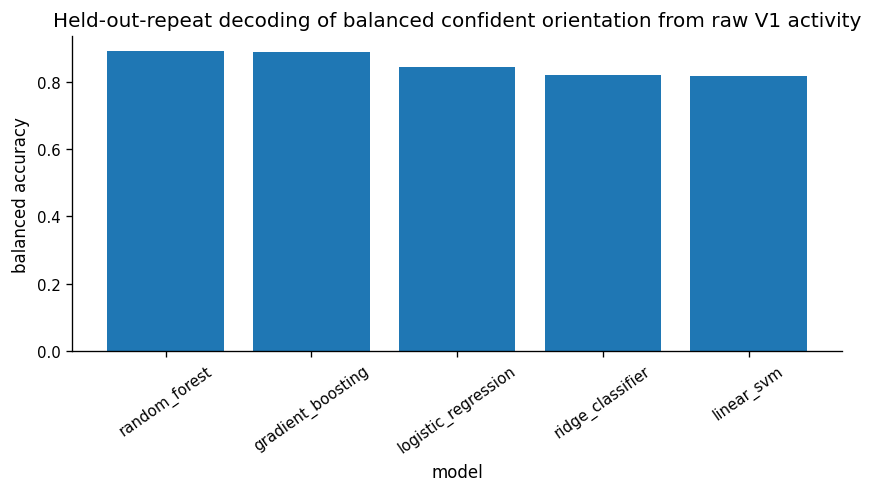

In [6]:
plot_df = benchmark[
    (~benchmark["is_null_baseline"].astype(bool))
    & (benchmark["target"] == "dominant_orientation_confident_balanced_binary_exploratory")
    & (benchmark["analysis"] == "balanced_confident_single_trial_repeat_heldout")
].copy()

fig = plot_metric_bar(
    plot_df,
    x="model",
    y="balanced_accuracy",
    title="Held-out-repeat decoding of balanced confident orientation from raw V1 activity",
)

save_figure(
    fig,
    paths.figures_dir / "06_raw_cells_balanced_confident_orientation_repeat_heldout.png",
)

plt.show()

,field,value
0,session_id,500855614
1,target,dominant_orientation_confident_balanced_binary...
2,analysis,balanced_confident_frame_level_exploratory
3,embedding,pca_full
4,model,linear_svm
5,n_samples,116
6,accuracy,0.991379
7,balanced_accuracy,0.991379
8,macro_f1,0.991379


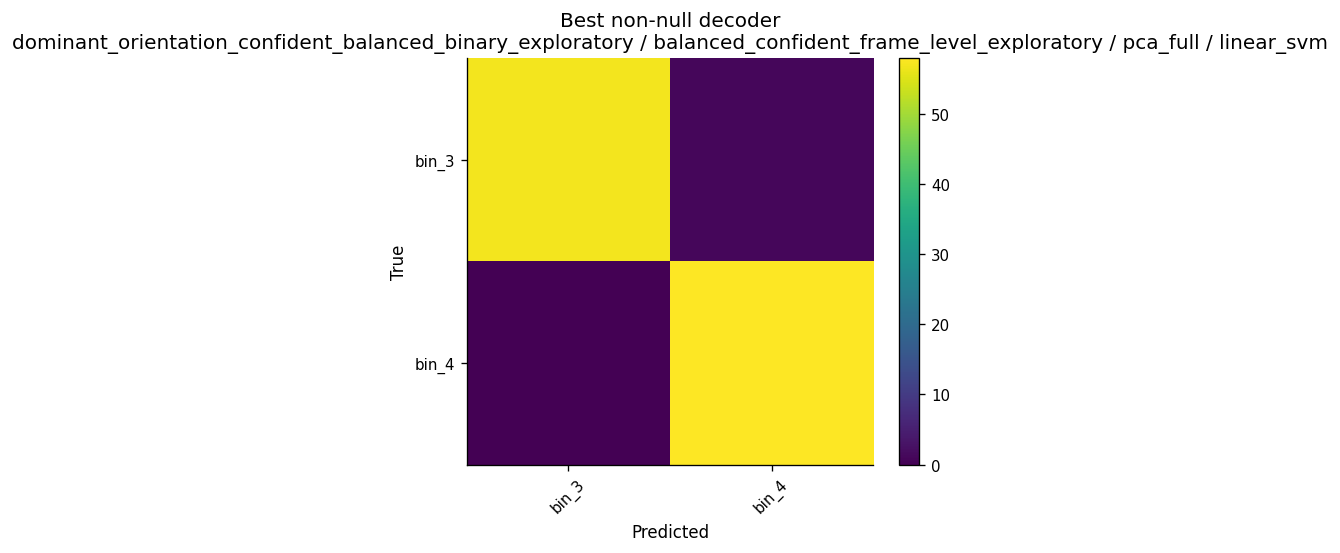

In [ ]:
# This cell reconstructs the correct y_true for ordinary targets and for the special
# balanced confident-orientation subset.

non_null = benchmark[~benchmark["is_null_baseline"].astype(bool)].copy()

if non_null.empty:
    raise RuntimeError("No non-null decoder results are available for confusion-matrix plotting.")

best = non_null.sort_values("balanced_accuracy", ascending=False).iloc[0]

key = (
    best["analysis"],
    best["target"],
    best["embedding"],
)

if key not in all_predictions:
    raise KeyError(
        f"The prediction key {key} was not found in all_predictions. "
        "This usually means the notebook kernel was restarted after the expensive decoding cell."
    )

y_pred = all_predictions[key][best["model"]]

target = best["target"]
analysis = best["analysis"]

if target == "dominant_orientation_confident_balanced_binary_exploratory":
    frame_subset = balanced_confident["movie_frame"].astype(int).to_numpy()
    y_balanced = balanced_confident["dominant_orientation_confident"].to_numpy()

    if analysis == "balanced_confident_frame_level_exploratory":
        y_true = y_balanced

    elif analysis == "balanced_confident_single_trial_repeat_heldout":
        frame_to_label = dict(zip(frame_subset, y_balanced))
        trial_mask = np.isin(frame_idx, frame_subset)
        y_true = np.array([frame_to_label[int(i)] for i in frame_idx[trial_mask]])

    else:
        raise ValueError(
            f"Unexpected analysis for balanced confident target: {analysis}"
        )

else:
    if target not in classification_targets:
        raise KeyError(
            f"{target} was not found in classification_targets. "
            "This target may be a derived subset and needs explicit handling."
        )

    if analysis == "single_trial_repeat_heldout":
        y_true = classification_targets[target][frame_idx]
    else:
        y_true = classification_targets[target]

# Safety check before plotting.
if len(y_true) != len(y_pred):
    raise ValueError(
        f"Confusion-matrix length mismatch: y_true has {len(y_true)} samples, "
        f"but y_pred has {len(y_pred)} predictions."
    )

labels_sorted = sorted(np.unique(np.concatenate([np.asarray(y_true), np.asarray(y_pred)])))

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels_sorted,
)

fig = plot_confusion_matrix(
    cm,
    labels=labels_sorted,
    title=(
        f"Best non-null decoder\n"
        f"{best['target']} / {best['analysis']} / {best['embedding']} / {best['model']}"
    ),
)

save_figure(
    fig,
    paths.figures_dir / "06_best_non_null_real_feature_confusion_matrix.png",
)

confusion_summary = pd.DataFrame({
    "field": [
        "session_id",
        "target",
        "analysis",
        "embedding",
        "model",
        "n_samples",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
    ],
    "value": [
        best["session_id"],
        best["target"],
        best["analysis"],
        best["embedding"],
        best["model"],
        len(y_true),
        best["accuracy"],
        best["balanced_accuracy"],
        best["macro_f1"],
    ],
})

save_table(
    confusion_summary,
    paths.tables_dir / "06_best_non_null_confusion_matrix_summary.csv",
)

display(confusion_summary)

plt.show()

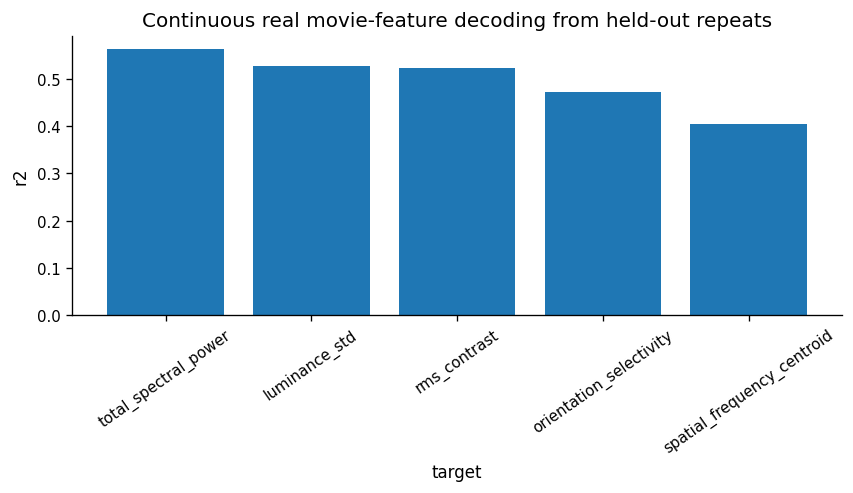

,target,session_id,analysis,embedding,mae,rmse,r2,model,n_samples,n_features
0,luminance_std,500855614,single_trial_repeat_heldout,raw_cells,0.004443,0.006865,0.528322,random_forest_regressor,9000,163
1,orientation_selectivity,500855614,single_trial_repeat_heldout,raw_cells,0.046945,0.064503,0.471925,random_forest_regressor,9000,163
2,rms_contrast,500855614,single_trial_repeat_heldout,raw_cells,0.008275,0.012827,0.522509,random_forest_regressor,9000,163
3,spatial_frequency_centroid,500855614,single_trial_repeat_heldout,raw_cells,0.006456,0.008813,0.404585,random_forest_regressor,9000,163
4,total_spectral_power,500855614,single_trial_repeat_heldout,raw_cells,15455.182967,21177.296663,0.562762,random_forest_regressor,9000,163


In [8]:
fig = plot_metric_bar(
    regression_benchmark,
    x="target",
    y="r2",
    title="Continuous real movie-feature decoding from held-out repeats",
)
save_figure(fig, paths.figures_dir / "06_continuous_feature_decoding_r2.png")
plt.show()

primary_regression_summary = (
    regression_benchmark
    .sort_values("r2", ascending=False)
    .groupby("target", as_index=False)
    .first()
)
save_table(
    primary_regression_summary,
    paths.tables_dir / "06_primary_continuous_decoding_summary.csv",
)
display(primary_regression_summary)